Imports

In [12]:
import math
import matplotlib.pyplot as plt

Function and its derivative

In [13]:
def f(m):
    return (9.81 * m / 15) * (1 - math.exp(-(15/m) * 10)) - 36

def df(m):
    return (9.81/15) * (1 - math.exp(-(15/m)*10)) - (9.81*10/m) * math.exp(-(15/m)*10)

Newton Raphson Method For Root Finding

In [14]:
def newton_raphson(x0, tol):
    print(f"""{'Iter':<5}{'x':<15}{'f(x)':<20}{"f'(x)":<20}{'xr(new)':<15}{'εa (%)':<15}""")
    print("-"*100)

    it = 0
    xr_old = x0
    errors = []

    while True:
        it += 1
        fx = f(xr_old)
        dfx = df(xr_old)

        if dfx == 0:
            print("Derivative zero. Not applicable")
            return None

        xr = xr_old - fx / dfx

 
        ea = abs((xr - xr_old) / xr) * 100
        errors.append(ea)

        print(f"{it:<5}{xr_old:<15.10f}{fx:<20.10f}{dfx:<20.10f}"
              f"{xr:<15.10f}{'' if ea is None else f'{ea:.10f}'}")

        if ea is not None and ea < tol :
            break

        xr_old = xr

    
    plt.figure()
    plt.plot(range(1, len(errors)+1), errors, marker='o')
    plt.xlabel('Iteration')
    plt.ylabel('Approximate Error (%)')
    plt.title('Convergence of Approximate Error in Newton-Raphson Method')
    plt.grid(True)
    plt.show()

    return xr

Main Function

Iter x              f(x)                f'(x)               xr(new)        εa (%)         
----------------------------------------------------------------------------------------------------
1    40.0000000000  -10.4552242316      0.5809421225        57.9970152390  31.0309335142
2    57.9970152390  -0.9258994341       0.4773978363        59.9364866059  3.2358776377
3    59.9364866059  -0.0106306924       0.4664627015        59.9592766219  0.0380091576
4    59.9592766219  -0.0000014529       0.4663352035        59.9592797374  0.0000051961


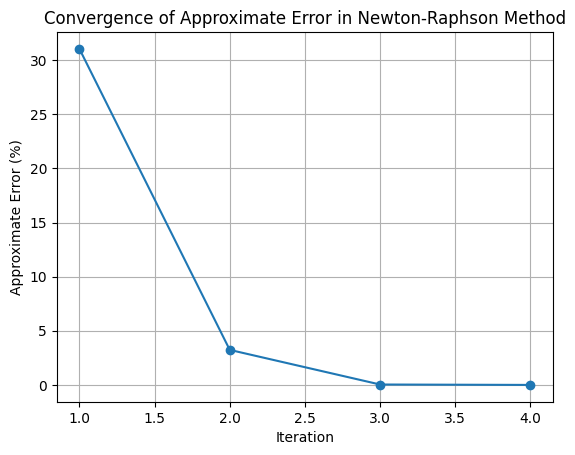


Approximate root: 59.9592797374



In [15]:
def main():
    m0 = 40
    tol = 0.001

    root = newton_raphson(m0, tol)
    print(f"\nApproximate root: {root:.10f}\n")

if __name__ == "__main__":
    main()